In [1]:
import pandas as pd

In [2]:
quality = pd.read_csv('data/Coffee_Qlty.csv').dropna()
quality.rename(columns={'Country.of.Origin':'Country',
                        'Harvest.Year':'Year'
                        }, inplace=True)
print(quality)

      REC_ID  Species Continent.of.Origin        Country    Year Expiration  \
1          1  Arabica              Africa       Ethiopia  2014.0   04/03/16   
4          4  Arabica              Africa       Ethiopia  2014.0   04/03/16   
6          6  Arabica       South America           Peru  2012.0   09/17/13   
9          9  Arabica              Africa       Ethiopia  2014.0   03/29/16   
18        18  Arabica                Asia          China  2015.0   04/07/17   
...      ...      ...                 ...            ...     ...        ...   
1307    1308  Arabica       North America      Nicaragua  2016.0   06/06/18   
1308    1309  Arabica       North America      Guatemala  2012.0   05/24/13   
1318    1319  Robusta                Asia          India  2015.0   08/17/17   
1321    1322  Robusta                Asia          India  2015.0   08/23/17   
1332    1333  Robusta       North America  United States  2012.0   02/28/13   

      Variety         Color Processing.Method  Arom

In [3]:
quality = quality.groupby(['Country','Year']).agg({
    'Aroma':'mean',
    'Flavor':'mean',
    'Aftertaste':'mean',
    'Acidity':'mean',
    'Balance':'mean',
    'Sweetness':'mean'
})
print(quality)

                         Aroma    Flavor  Aftertaste   Acidity   Balance  \
Country       Year                                                         
Brazil        2011.0  8.141000  7.992000    7.791000  7.784000  7.816000   
              2012.0  7.625000  7.600000    7.408500  7.500500  7.513000   
              2013.0  7.537143  7.511429    7.405714  7.452857  7.512857   
              2014.0  7.421176  7.548235    7.461765  7.431765  7.518824   
              2015.0  7.401818  7.559545    7.359545  7.480455  7.580000   
...                        ...       ...         ...       ...       ...   
United States 2012.0  7.523810  7.574762    7.447143  7.594762  7.655238   
              2013.0  7.515455  7.544545    7.522727  7.597273  7.683636   
              2014.0  7.461818  7.309091    7.332727  7.463636  7.470000   
Vietnam       2012.0  7.670000  8.000000    7.170000  7.080000  7.080000   
              2014.0  7.333333  7.443333    7.470000  7.500000  7.473333   

           

In [4]:
exports = pd.read_csv('data/psd_coffee.csv').dropna()
exports = exports.groupby(['Country', 'Year']).agg({'Exports':'mean'})
print(exports)

               Exports
Country  Year         
Albania  1960      0.0
         1961      0.0
         1962      0.0
         1963      0.0
         1964      0.0
...                ...
Zimbabwe 2019      0.0
         2020      0.0
         2021      0.0
         2022      0.0
         2023      0.0

[5376 rows x 1 columns]


In [5]:
data = quality.merge(exports, on=['Country','Year'])
print(data)

                         Aroma    Flavor  Aftertaste   Acidity   Balance  \
Country       Year                                                         
Brazil        2011.0  8.141000  7.992000    7.791000  7.784000  7.816000   
              2012.0  7.625000  7.600000    7.408500  7.500500  7.513000   
              2013.0  7.537143  7.511429    7.405714  7.452857  7.512857   
              2014.0  7.421176  7.548235    7.461765  7.431765  7.518824   
              2015.0  7.401818  7.559545    7.359545  7.480455  7.580000   
...                        ...       ...         ...       ...       ...   
United States 2012.0  7.523810  7.574762    7.447143  7.594762  7.655238   
              2013.0  7.515455  7.544545    7.522727  7.597273  7.683636   
              2014.0  7.461818  7.309091    7.332727  7.463636  7.470000   
Vietnam       2012.0  7.670000  8.000000    7.170000  7.080000  7.080000   
              2014.0  7.333333  7.443333    7.470000  7.500000  7.473333   

           

In [6]:
data.reset_index(inplace=True)
print(data)

           Country    Year     Aroma    Flavor  Aftertaste   Acidity  \
0           Brazil  2011.0  8.141000  7.992000    7.791000  7.784000   
1           Brazil  2012.0  7.625000  7.600000    7.408500  7.500500   
2           Brazil  2013.0  7.537143  7.511429    7.405714  7.452857   
3           Brazil  2014.0  7.421176  7.548235    7.461765  7.431765   
4           Brazil  2015.0  7.401818  7.559545    7.359545  7.480455   
..             ...     ...       ...       ...         ...       ...   
99   United States  2012.0  7.523810  7.574762    7.447143  7.594762   
100  United States  2013.0  7.515455  7.544545    7.522727  7.597273   
101  United States  2014.0  7.461818  7.309091    7.332727  7.463636   
102        Vietnam  2012.0  7.670000  8.000000    7.170000  7.080000   
103        Vietnam  2014.0  7.333333  7.443333    7.470000  7.500000   

      Balance  Sweetness  Exports  
0    7.816000  10.000000  29843.0  
1    7.513000   9.966500  30660.0  
2    7.512857  10.000000  3

In [41]:
corr_data = pd.DataFrame()

for country in data['Country'].unique():
    corr = pd.DataFrame(data[data['Country']==country][['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Balance', 'Sweetness', 'Exports']].corr()['Exports'][:-1]).transpose()
    corr['Country'] = country
    corr_data = pd.concat([corr_data, corr], ignore_index=True)

corr_data.dropna(inplace=True, ignore_index=True)
print(corr_data)

       Aroma    Flavor  Aftertaste   Acidity   Balance  Sweetness  \
0  -0.678003 -0.519957   -0.498337 -0.697097 -0.222101  -0.587205   
1   1.000000  1.000000    1.000000  1.000000  1.000000   1.000000   
2   0.685296  0.659555    0.632793  0.592004  0.858022   0.451532   
3   0.195547  0.494042    0.228875  0.592065  0.084023   0.268953   
4   0.239023 -0.571890   -0.823189  0.010689 -0.468026   0.321597   
5  -0.392337 -0.374284    0.317261 -0.319874  0.737882  -0.912560   
6  -1.000000 -1.000000   -1.000000 -1.000000 -1.000000  -1.000000   
7   0.464766  0.447354   -0.178744 -0.185751 -0.044296   0.366444   
8   0.419693  0.724390    0.621173  0.797476 -0.186020   0.359039   
9  -0.294880 -0.281189   -0.262222  0.121201 -0.260546  -0.769445   
10  0.652574  0.203868   -0.743565  0.235911 -0.448892  -0.535568   
11  1.000000  1.000000    1.000000  1.000000  1.000000   1.000000   
12 -0.553455 -0.442113   -0.399588 -0.095263 -0.469374  -0.021216   
13  0.224384  0.388931    0.539753

In [ ]:
corr_data.to_csv('data/corr_quality_exports.csv')

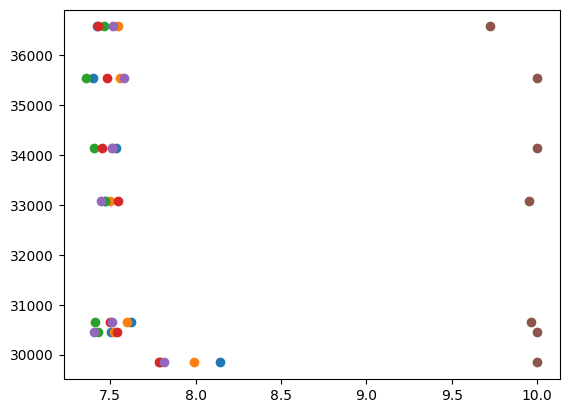

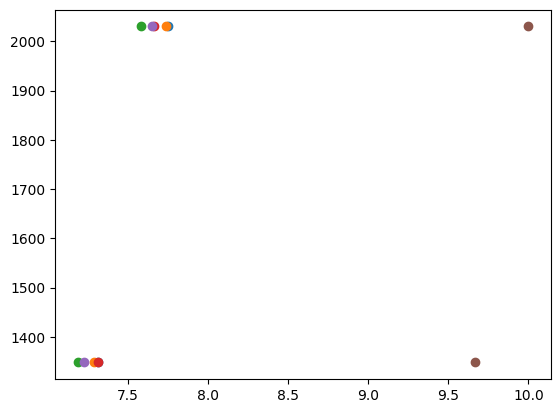

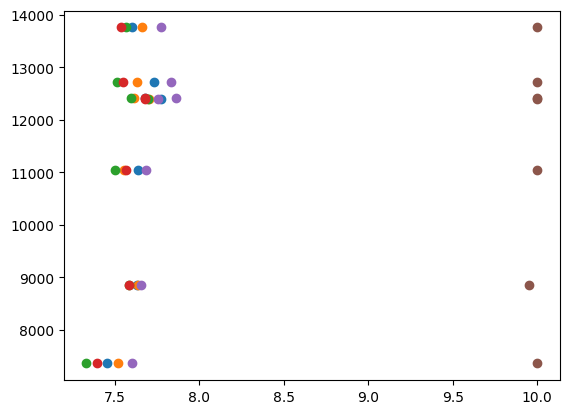

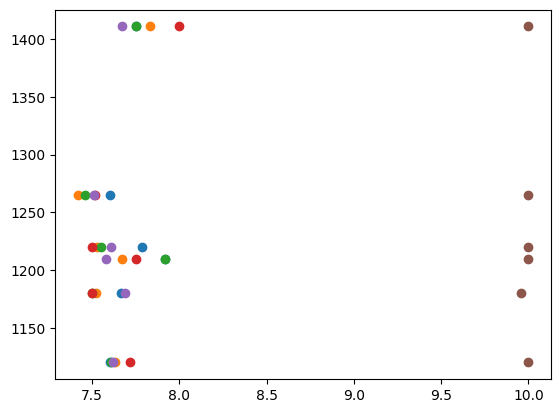

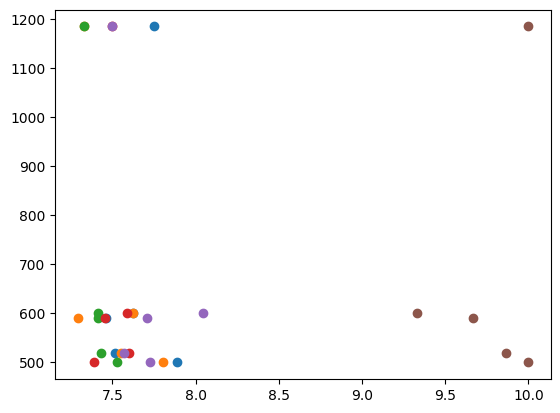

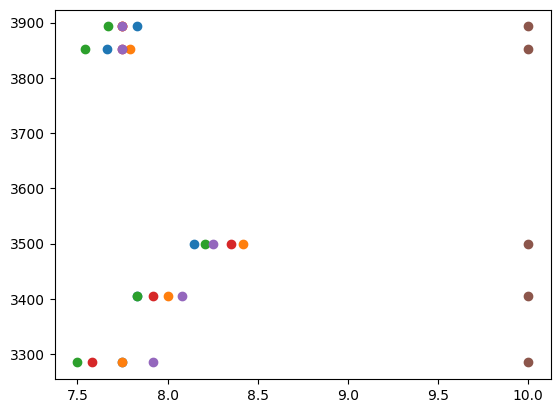

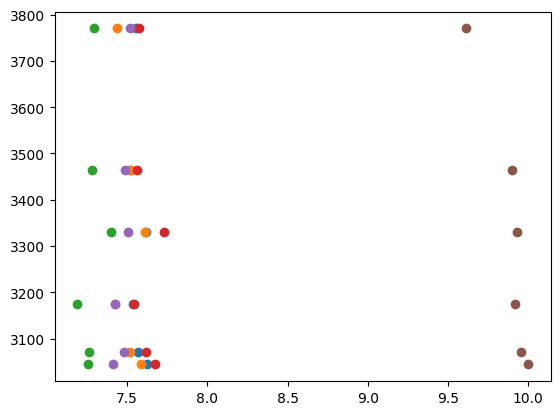

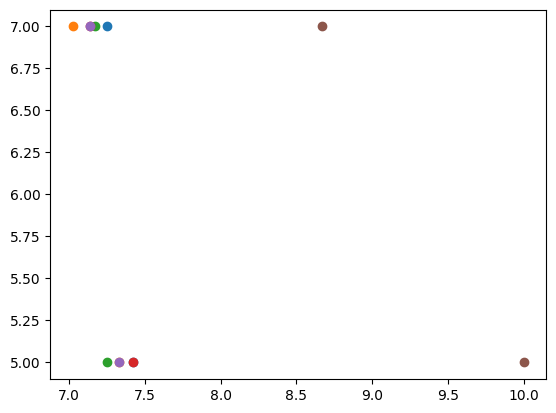

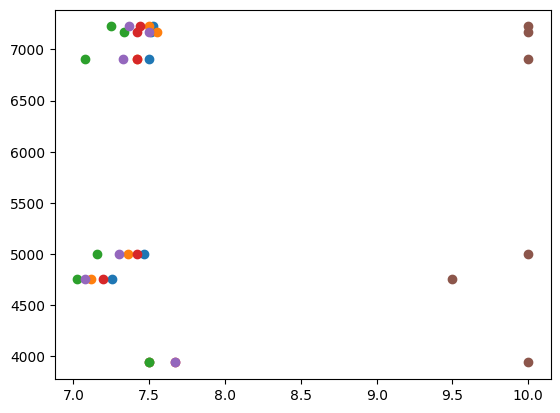

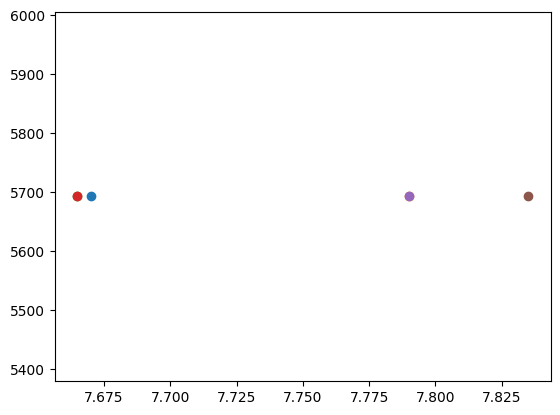

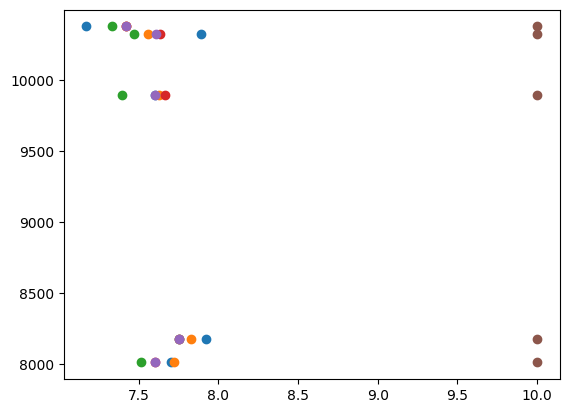

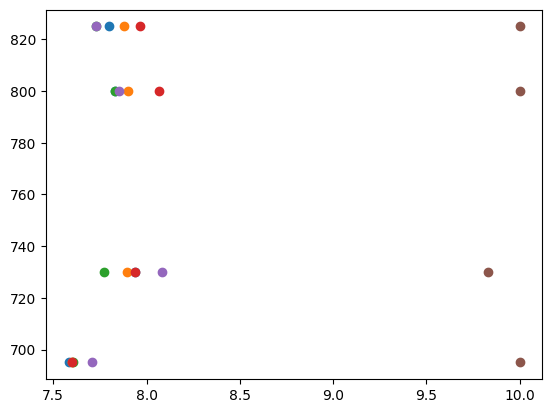

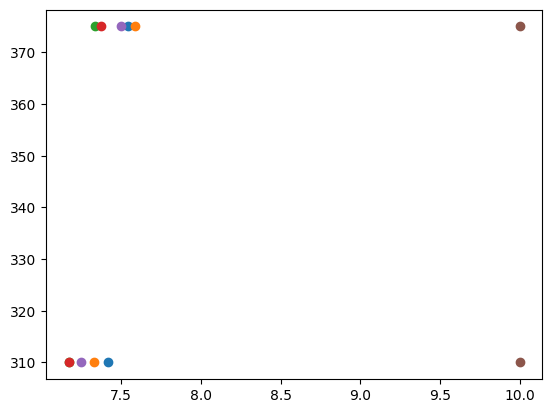

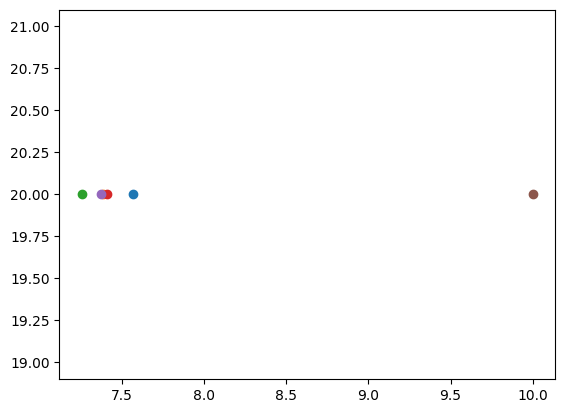

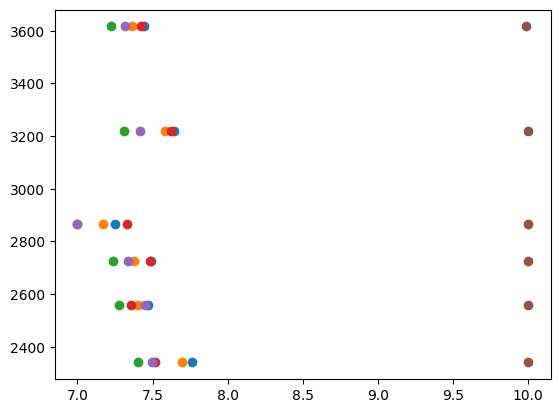

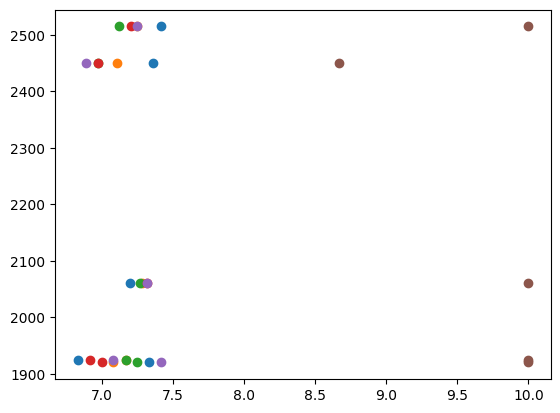

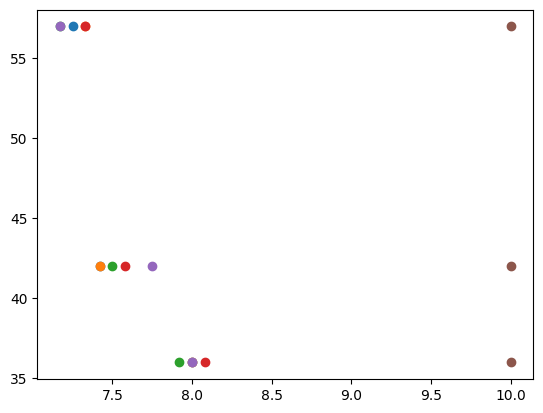

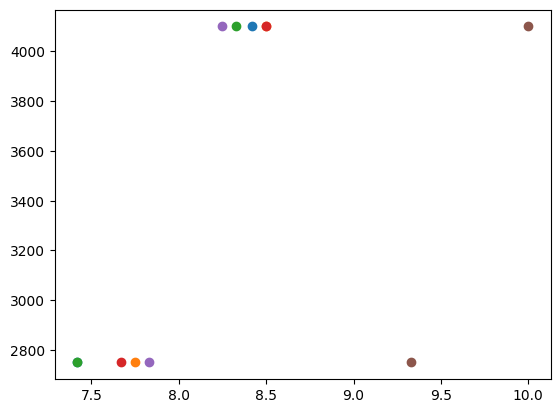

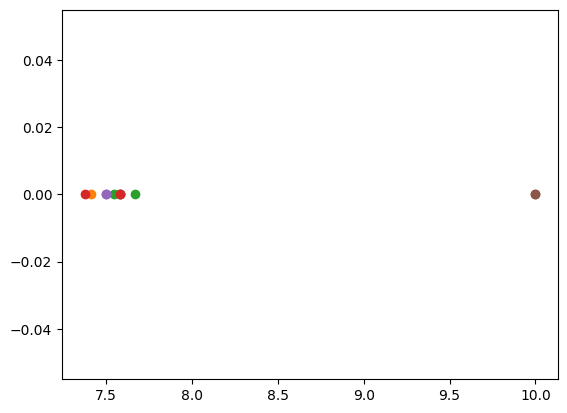

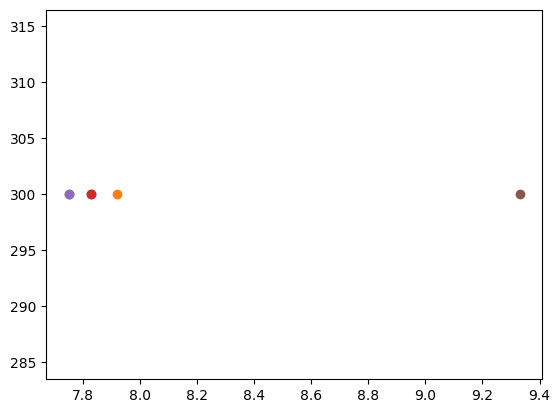

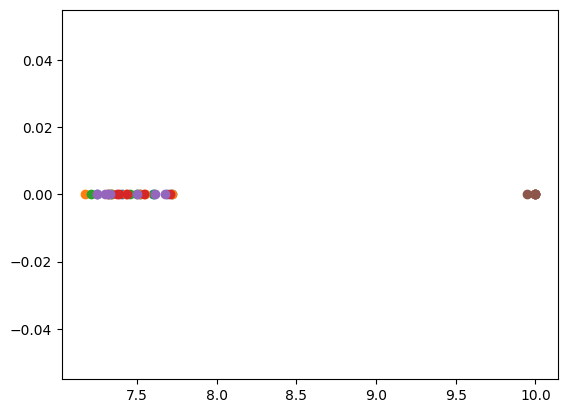

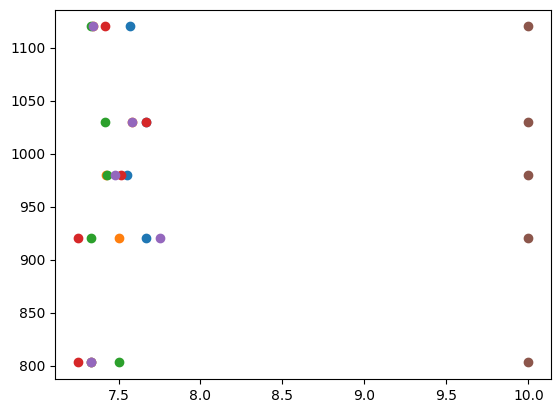

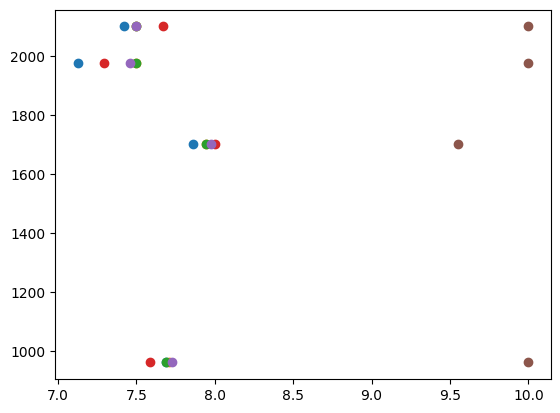

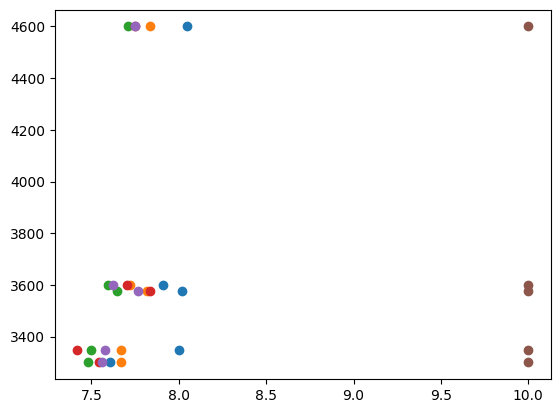

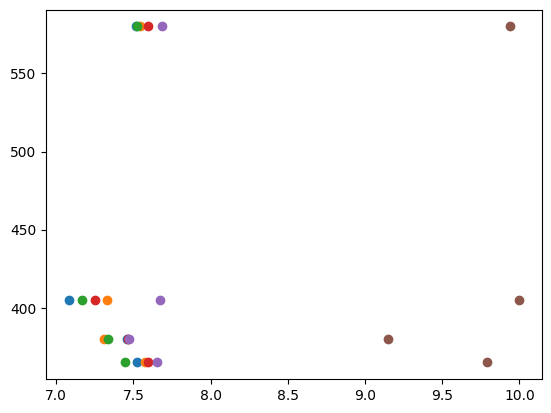

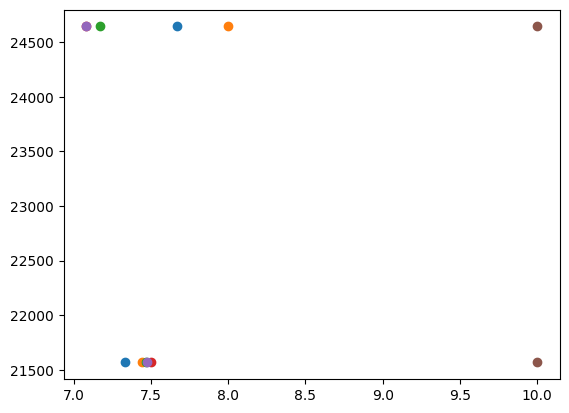

In [44]:
import matplotlib.pyplot as plt

for country in data['Country'].unique():
    plt.plot(data[data['Country']==country][['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Balance', 'Sweetness']], data[data['Country']==country]['Exports'], 'o')
    plt.show()